# Results Loader and Plots Comparison for all Models

In [1]:
from pathlib import Path

import pandas as pd

from config.config import Config
from src.data import time_series_split
from src.plots import plot_forecast_diagnostics, plot_forecast_overlay, plot_return_overlay, plot_test_overlay, plot_val_overlay
from src.utils import load_results_from_dir, results_to_df, set_seed

In [2]:
cfg = Config.load()
SEED = cfg.runtime.seed
HORIZON = cfg.runtime.horizon
TARGET_MODE = cfg.runtime.target_mode
SAVE = True
rng = set_seed(SEED)

OUT_DIR = Path(cfg.data.processed_dir)
FIG_DIR = Path(cfg.data.fig_dir)

2025-09-14 11:27:54,127 - INFO - src.utils - Global random seed set to 42


In [3]:
results = load_results_from_dir(OUT_DIR)
len(results), [r["kind"] for r in results]

(1, ['linreg'])

In [4]:
df_full = pd.read_csv(Path(cfg.data.processed_dir) / "features_full.csv")
train, val, test, forecast = time_series_split(df_full, train_ratio=0.8, val_ratio=0.1, horizon=HORIZON)

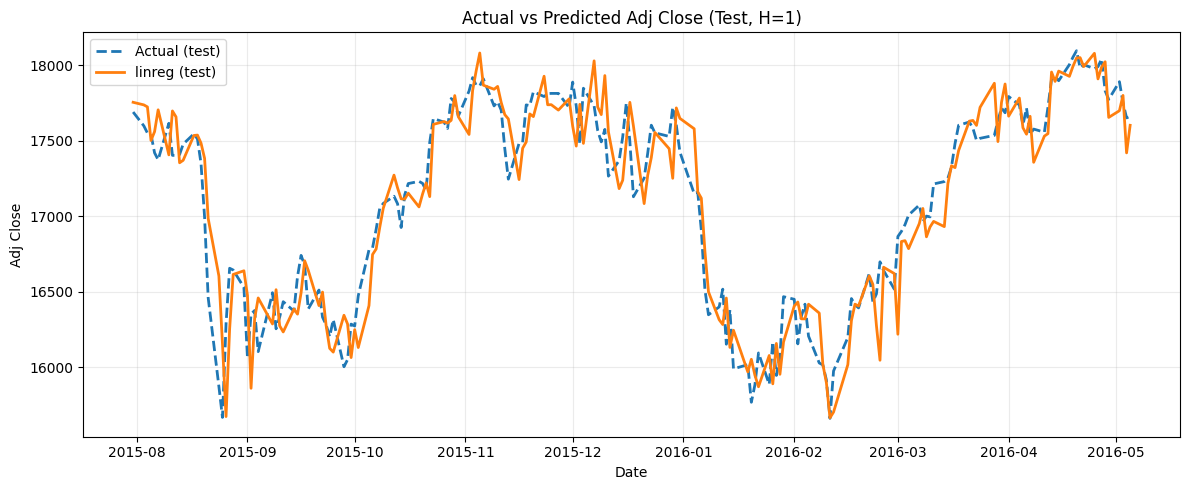

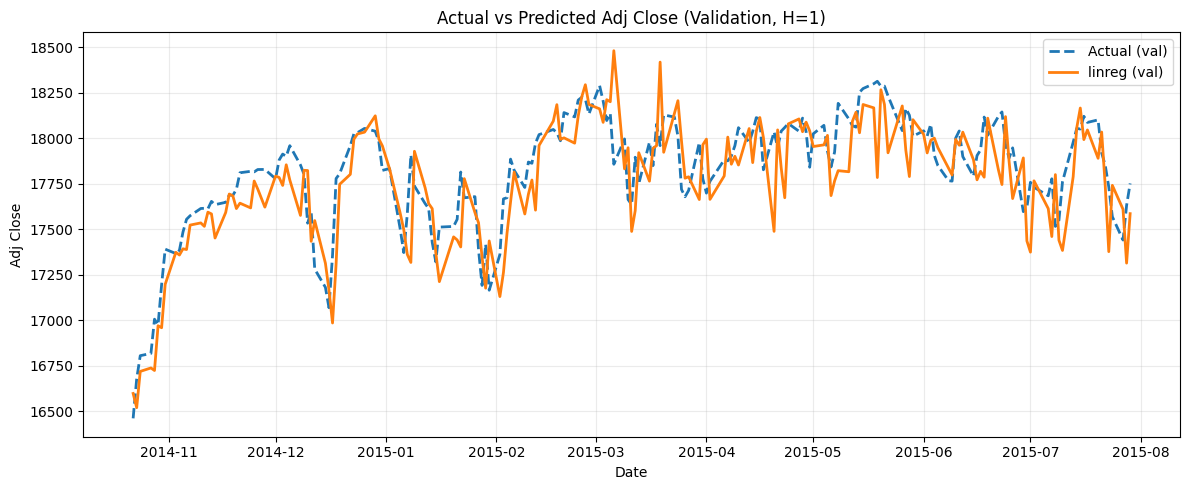

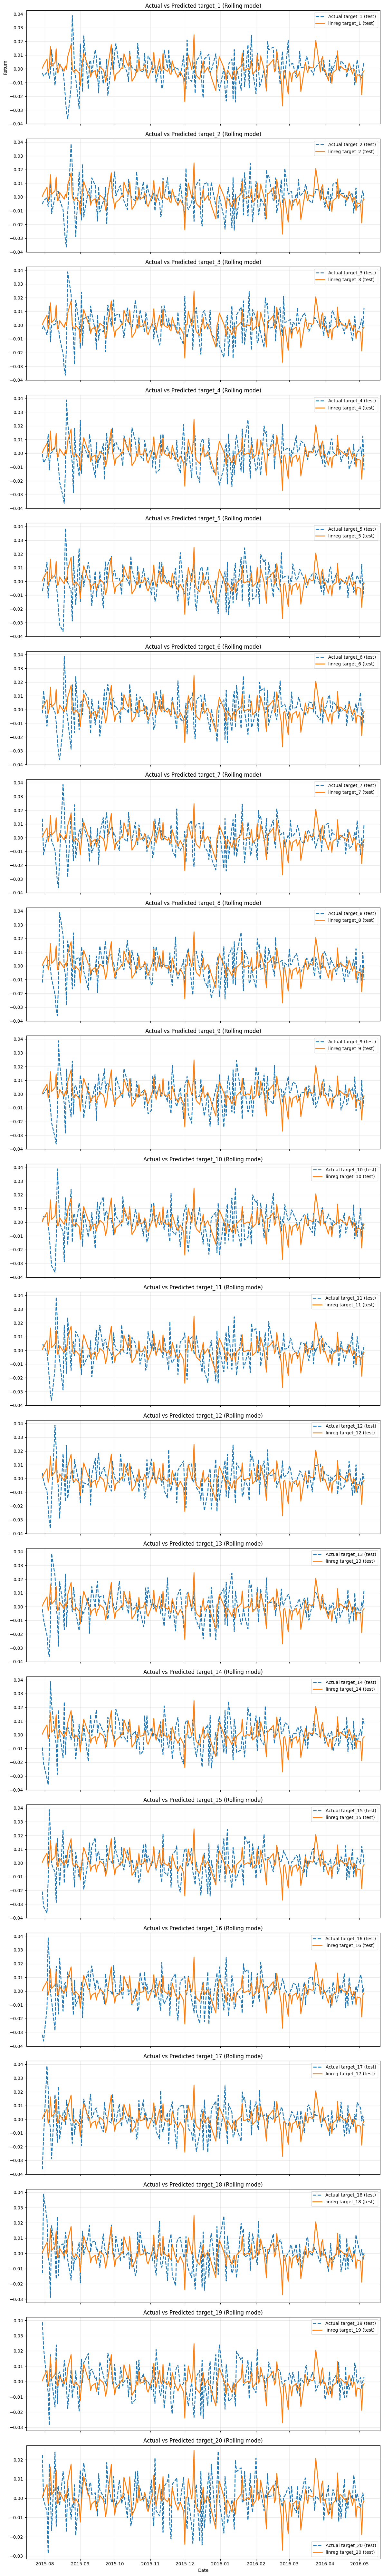

In [5]:
plot_test_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_actual_vs_predicted_adj_close_test.png", save=SAVE)
plot_val_overlay(val, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_actual_vs_predicted_adj_close_val.png", save=SAVE)
plot_return_overlay(test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_returns.png", phase="test", target_mode=TARGET_MODE, save=SAVE)
if TARGET_MODE == "step":
    plot_forecast_overlay(test, forecast, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_forecast.png", save=SAVE)
    plot_forecast_diagnostics(forecast, test, results, Path(cfg.data.fig_dir) / "all_actual_vs_predicted_adj_close_forecast_diagnostics.png", save=SAVE)

In [6]:
params_summary = results_to_df(results, "best_params")
params_summary

,model,alpha,l1_ratio,max_iter,eta0,learning_rate,random_state
0,linreg,0.008862,0.95008,1000,0.00158,constant,42


In [7]:
metrics_summary = results_to_df(results, ["metrics", "test", "aggregate"])
metrics_summary

,model,mae,mse,rmse,r2,directional_accuracy
0,linreg,0.021614,0.000968,0.031106,-0.062685,0.471601
